# The bias-variance tradeoff

In [7]:
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import norm
import scipy.stats as stats
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier





# Data generation
Given two Gaussian mixtures (each made up of $m$ Gaussians) 
$$
\rho_0 = \frac{1}{m} \sum_{k=1}^m \mathcal{N}(m^0_k, \sigma^2 I) \quad \text{and} \quad  \rho_1 = \frac{1}{m} \sum_{k=1}^m \mathcal{N}(m^1_k, \sigma^2 I),
$$
generate data $(X_i,Y_i)\in \mathbb{R}^2\times \{0,1\}$ for $i=1,\ldots, n$ as follows:

-  We also assume that $\mathbb{P}(Y=1) = q$ and $\mathbb{P}(Y=0) = 1-q$. 
- 
If $Y_i = 0$, then $X_i$ is sampled from $\rho_0$, otherwise, it is sampled from $\rho_1$. 

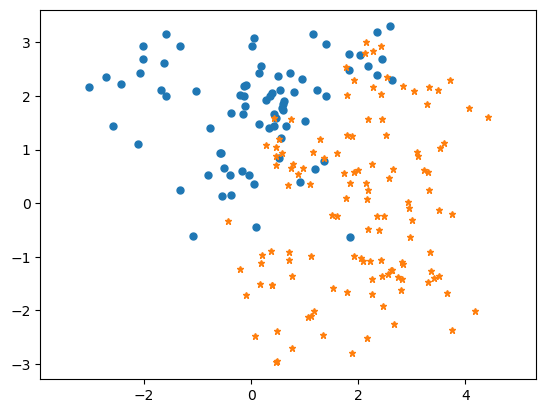

In [8]:
# Generate data
m=15
means = np.zeros((2,2,m)) #means[:,0,:] are the means for rho_0 and means[:,1,:] are the means for rho_1
for i in range(m):
    means[:,:,i] = 1.5*np.eye(2)+rnd.randn(2,2)
    
sigma = np.sqrt(0.2)
q = 0.4

# n = number of data points
# sigma = real positive number
# means = (2,2,m)
def generate_data(n,means,sigma):
    m = len(means[0,0,:])
    X = np.zeros((n,2))
    y = np.zeros(n)
    for i in range(n):       
        y[i] = rnd.binomial(1,q) #y_i = binom(q)
                
        if y[i] == 0:
            # sample from rho_0
            j = rnd.randint(m)
            X[i,:] = means[:,0,j]+sigma*rnd.randn(2)
        else:
            # sample from rho_1
            j = rnd.randint(m)
            X[i,:] = means[:,1,j]+sigma*rnd.randn(2)
    return X,y

n = 200 # number of samples
X,y = generate_data(n,means,sigma)
 
#plot the data
fig, ax = plt.subplots(1)
ax.plot(X[y==1,0],X[y==1,1],'o', X[y==0,0],X[y==0,1],'*', markersize=5)
plt.axis('equal')
plt.show()


# Nearest neighbour classifier

In [9]:
#create KNN classifiers for different number of neighbours
nrclf = 150
clflist = [KNeighborsClassifier(n_neighbors=k) for k in range(1,nrclf)]


#Train each classifier on the data 
for clf in clflist:
    clf.fit(X,y)
    
    

Plot the decision boundaries

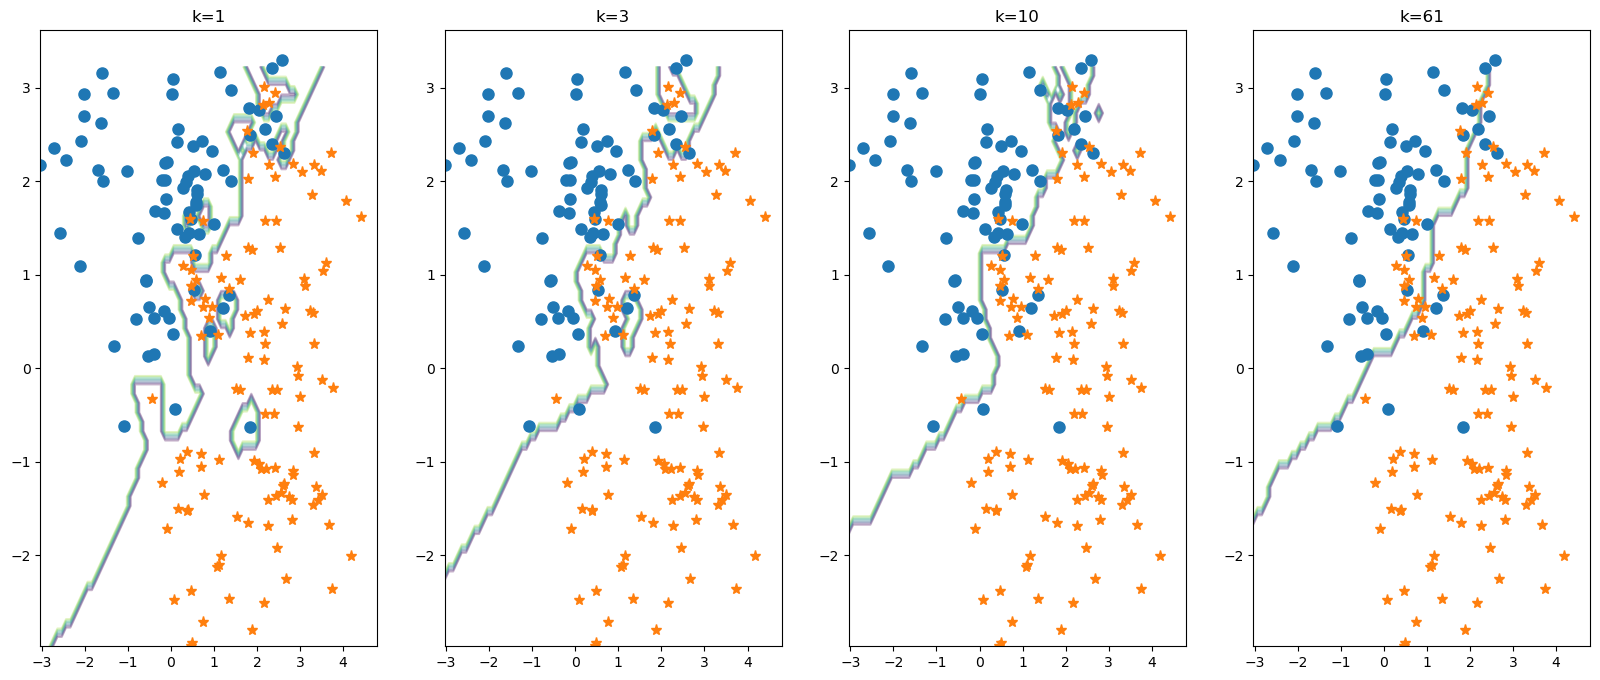

In [10]:
# Plotting decision regions
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

fig, ax = plt.subplots(1,4, figsize=(20,8))

Nvals = [0,2,9,60]

for i,idx  in enumerate(Nvals):
    idx = Nvals[i]
    # Apply classifier to grid points
    Z = clflist[idx].predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax[i].contour(xx, yy, Z, alpha=0.3)
    ax[i].plot(X[y==1,0], X[y==1,1],'o', X[y==0,0],X[y==0,1],'*', markersize='8')
    ax[i].set_title('k=' + str(idx+1))


#plt.show()
plt.savefig('knn-experiment.png')



# Plot the accuracy

In [11]:
train_accuracy = np.zeros(nrclf)
for i,clf in enumerate(clflist):
    train_accuracy[i] = sum(y != clf.predict(X))/(n)
    
    

In [12]:
# Generate test data 

n_test = 10000
X_test,y_test = generate_data(n_test,means,sigma)

test_accuracy = np.zeros(nrclf)
for i,clf in enumerate(clflist):
    test_accuracy[i] = sum(y_test != clf.predict(X_test))/(n_test)
    
    

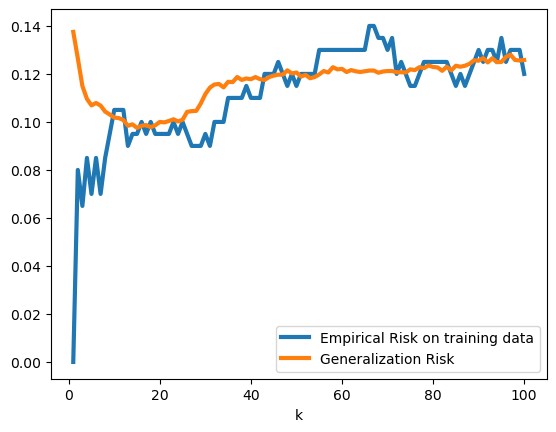

<Figure size 640x480 with 0 Axes>

In [13]:
N = 100
plt.plot(np.linspace(1,N,N),train_accuracy[:N],linewidth='3', label='Empirical Risk on training data')
plt.plot(np.linspace(1,N,N),test_accuracy[:N], linewidth='3', label='Generalization Risk')
plt.legend()
plt.xlabel('k')
plt.show()
plt.savefig('bias-variance.png')



# Bayes classifier

In this case, since we know that data distribution, we can compute Bayes classifier: we define 
\begin{align}
\eta(x)& = \mathbb{P}(Y=1|X= x) = \frac{ \mathbb{P}(X=x|Y=1) \mathbb{P}(Y=1)}{\mathbb{P}(X=x)}= \frac{\rho_1(x) \cdot q}{q \rho_1(x) + (1-q)\rho_0(x)}.
\end{align}
The Bayes classifier is 
$$
h(x) = \begin{cases}
1 & \eta(x)>\frac12,\\
0 & \eta(x)\leq \frac12.
\end{cases}
$$


First define $ q \rho_1(x) + (1-q)\rho_0(x)$:

In [14]:
# Compute Bayes risk

def total_dens(x):
    y = 0.
    for j in range(m):
        y +=(1-q)* stats.multivariate_normal.pdf(x, mean= means[:,0,j], cov=sigma**2*np.eye(2))
        y += q*stats.multivariate_normal.pdf(x, mean= means[:,1,j], cov=sigma**2*np.eye(2))
    return y



Then define $q\rho_1$:

In [15]:
def partial_dens(x):
    y = 0.
    for j in range(m):
        y += q*stats.multivariate_normal.pdf(x, mean= means[:,1,j], cov=sigma**2*np.eye(2))
    return y



generate new data and run the Bayes estimator

In [16]:

n_bayes = 10000
X_bayes, y_bayes =  generate_data(n_bayes,means,sigma)

ctr = 0.
h = 0
var = sigma**2
for j in range(n_bayes):
    
    x = X_bayes[j,:]
    
    #Bayes estimator applied to x
    if partial_dens(x)/total_dens(x)>=0.5:
        h = 1
    else:
        h = 0
        
    if h!=y_bayes[j]:
        ctr += 1.
ctr = ctr/(n_bayes)



In [17]:
print('Bayes risk =', ctr)



Bayes risk = 0.0981
